# Testing topographic variables

The reason to look at spatial extent of rainfall (rather than just the peak-cell value) was the hypothesis that a wider area of heavy rain matters for lateral convergence/routing into the target cell. 

But if storms in the dataset are fairly spatially coherent — i.e., events with a high peak intensity also tend to have a large area of exceedance around that peak, simply because that's how convective storms are structured — then max_precip (single-cell) and cluster_rain_total (area-integrated) end up highly correlated with each other in practice, even though conceptually they're answering different questions.

This is an argument for not including it in the model. Although might we want to check whether this holds in the future climate?

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
import shap
import seaborn as sns

def grouped_permutation_importance(model, X, y, groups, n_repeats=10, random_state=42):
    """
    groups: dict mapping group_name -> list of column names to permute together
    """
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    results = {}
    
    for group_name, cols in groups.items():
        drop_scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # Shuffle all columns in the group using the SAME row order,
            # so their joint relationship is scrambled together
            shuffled_idx = rng.permutation(len(X_permuted))
            X_permuted[cols] = X_permuted[cols].values[shuffled_idx]
            score = model.score(X_permuted, y)
            drop_scores.append(baseline_score - score)
        results[group_name] = {
            'importance_mean': np.mean(drop_scores),
            'importance_std': np.std(drop_scores)
        }
    return pd.DataFrame(results).T.sort_values('importance_mean', ascending=False)

def loco_test(X_full, y, drop_var, cv):
    X_reduced = X_full.drop(columns=[drop_var])
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def loco_test_vars(X_full, y, drop_vars, cv):
    X_reduced = X_full.drop(columns=drop_vars)
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

### Get event data

In [2]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
rainfall_events_all_df['random_variable'] = np.random.normal(size=len(rainfall_events_all_df))

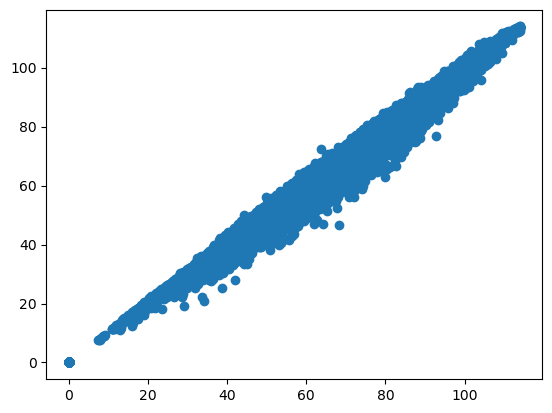

In [91]:
plt.scatter(rainfall_events_all_df['mean_sm_2_before_event'], rainfall_events_all_df['mean_sm_5_before_event'])

In [73]:
rainfall_events_all_df[['peak_cell_outflow_N', 
                        'peak_cell_outflow_S', 'peak_cell_outflow_E','peak_cell_outflow_W']]=rainfall_events_all_df[[
    'peak_cell_outflow_N', 'peak_cell_outflow_S', 'peak_cell_outflow_E','peak_cell_outflow_W']].fillna(value=0)

In [76]:
def net_flux_score(edge_scores, edge_truncated):
    """
    Net flux score for the cell, treating a truncated (catchment-boundary)
    edge as a genuine zero-flux boundary rather than missing data --
    water cannot cross a hydrological divide, so 0 is the physically
    correct value there, not an unknown.

    Positive: net tendency for the cell to shed water outward overall.
    Negative: net tendency for flow to converge within the cell (sink-like).

    Returns the mean over all 4 edges (NaN -> 0 filled). Multiply by 4
    for the equivalent sum -- same ranking, different scale.
    """
    filled = [0.0 if edge_truncated[d] else edge_scores[d] for d in 'NSEW']
    return float(np.mean(filled))

outflow_cols = ['peak_cell_outflow_N', 'peak_cell_outflow_S',
                 'peak_cell_outflow_E', 'peak_cell_outflow_W']
truncated_cols = ['peak_cell_edge_truncated_N', 'peak_cell_edge_truncated_S',
                   'peak_cell_edge_truncated_E', 'peak_cell_edge_truncated_W']

# zero-fill only where truncated == True; leave real values elsewhere
filled = rainfall_events_all_df[outflow_cols].copy()
for out_col, trunc_col in zip(outflow_cols, truncated_cols):
    filled.loc[rainfall_events_all_df[trunc_col], out_col] = 0.0

rainfall_events_all_df['peak_cell_net_flux_score'] = filled.mean(axis=1)
# or, for the sum version instead:
# rainfall_events_all_df['peak_cell_net_flux_score'] = filled.sum(axis=1)

In [77]:
subset = rainfall_events_all_df# [rainfall_events_all_df["catchment_num"].isin(['33_b', '23', '105', '40', '106', '25'])].copy()
subset = subset.sample(n=5000, random_state=42)  # adjust size to something that runs in seconds
subset.reset_index(inplace=True, drop=True)

### Feature selection

Remove variables which carry no meaning

In [78]:
variables = list(subset.columns)
to_be_removed = {'x_coord', 'y_coord',
                'x_idx', 'y_idx', 'x_idx_global', "y_idx_global", 't_global','t_local', "day_360", "month",
                 "max_precip_from_csv", "event_num", "time_mismatch", "ens",  'start_idx', 'stop_idx',
                 "t_local_rebased", "times", "values", "mismatch", 'n_valid', 'pct_over1', 'pct_under0',
                # "10cm_volume", "30cm_area", "30cm_volume", "10cm_area", 
                'mean_sm_3_before_event', 'mean_sm_4_before_event', 'mean_sm_5_before_event', 'neighbourhood_flood_10_area',
                 'neighbourhood_flood_10_vol', 'neighbourhood_flood_30_area', 'neighbourhood_flood_30_vol',
                'threshold_flood_10_area_t50', 'cluster_flood_10_area_t50',  'threshold_flood_10_vol_t50',
                 'cluster_flood_10_vol_t50', 'threshold_flood_30_area_t50', 'cluster_flood_30_area_t50',
                 'threshold_flood_30_vol_t50','cluster_flood_30_vol_t50','threshold_flood_10_area_t60',
                 'cluster_flood_10_area_t60','threshold_flood_10_vol_t60','cluster_flood_10_vol_t60',
                 'threshold_flood_30_area_t60','cluster_flood_30_area_t60','threshold_flood_30_vol_t60',
                 'cluster_flood_30_vol_t60','threshold_flood_10_area_t80', 'cluster_flood_10_area_t80',
                 'threshold_flood_10_vol_t80', 'cluster_flood_10_vol_t80', 'threshold_flood_30_area_t80',
                 'cluster_flood_30_area_t80', 'threshold_flood_30_vol_t80','cluster_flood_30_vol_t80', 
                 'event_num.1', 'date','Unnamed: 0', 'peak_cell_id',"rainfall_peak_day", "catchment_num",
                 'peak_cell_edge_truncated_N', 'peak_cell_edge_truncated_S', 'peak_cell_edge_truncated_E',
                 'peak_cell_edge_truncated_W',"peak_cell_near_catchment_boundary",
                 'se_min', 'se_max'}

subset = subset.drop(columns=to_be_removed, errors='ignore').copy()
# subset = subset.dropna().copy()

Remove variables which describe rainfall inputs at different spatial scales

- Threshold: any cell anywhere in the domain with rainfall over a certain threshold
- Cluster: cells with rainfall over a certain threshold, which are contiguous with the peak rainfall cell
- Neighbourhood: cells within a fixed spatial window around the peak cell. All rainfall in any of those cells is counted

Cluster seems to be the most physically meaningful option.

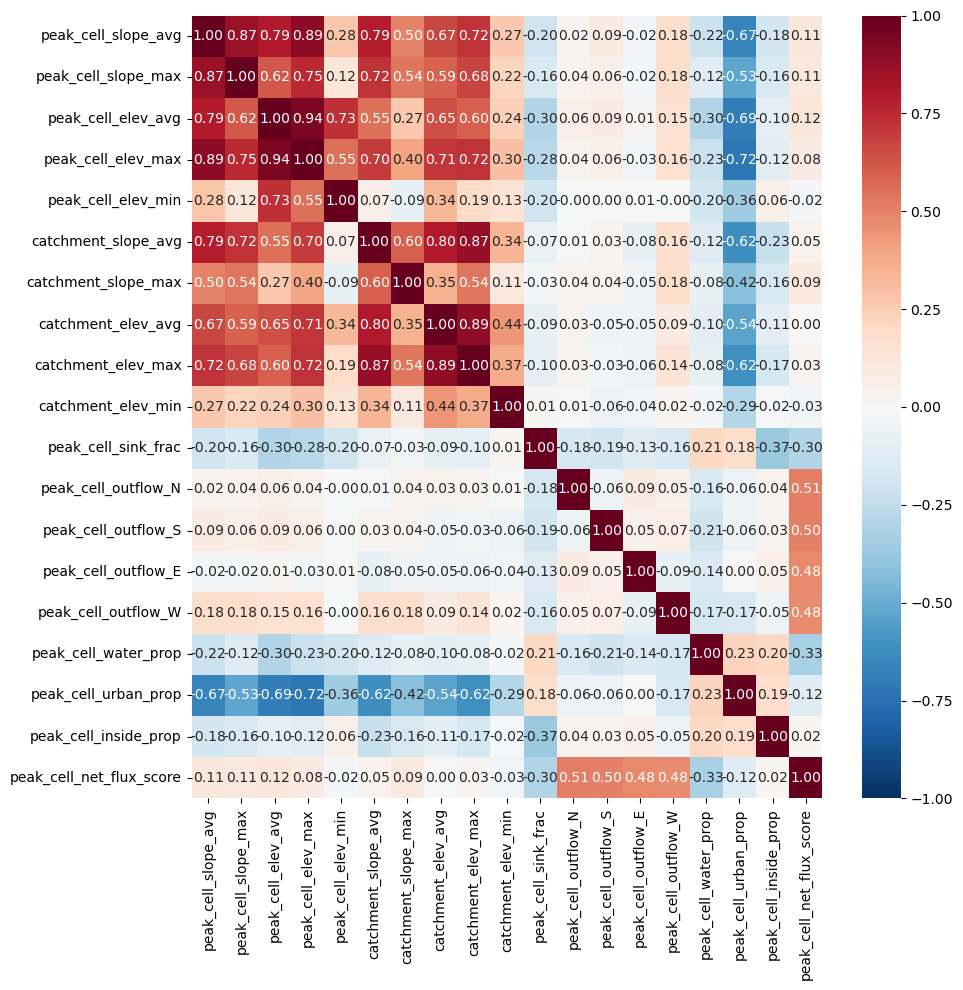

In [81]:
topo_vars = [#'x_coord' , 'y_coord', 
            'peak_cell_slope_avg', 'peak_cell_slope_max', 'peak_cell_elev_avg', 'peak_cell_elev_max', 'peak_cell_elev_min', 
             'catchment_slope_avg', 'catchment_slope_max', 'catchment_elev_avg', 'catchment_elev_max', 'catchment_elev_min',
             'peak_cell_sink_frac', 'peak_cell_outflow_N', 'peak_cell_outflow_S', 'peak_cell_outflow_E', 'peak_cell_outflow_W',
             'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop','peak_cell_net_flux_score']

corr = subset[topo_vars].corr(method='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

### Create baseline version of model with all variables included

In [80]:
rf = RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42)
lr = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [85]:
predictor_variables = [col for col in subset.columns if col not in ['10cm_area', '10cm_volume', '30cm_area', '30cm_volume']]

# Define X (predictors) and Y (response)
X = subset[predictor_variables]
y = subset['10cm_area']

In [24]:
baseline_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2').mean()
print(f"Full model R²: {baseline_r2:.4f}\n")

Full model R²: 0.7994



### Test whether dropping any of the cluster rain vars decreases model performance

In [82]:
peak_cell_elevation_vars = ['peak_cell_slope_avg', 'peak_cell_slope_max', 'peak_cell_elev_avg', 'peak_cell_elev_max', 
                            'peak_cell_elev_min']
catchment_elevation_vars = ['catchment_slope_avg', 'catchment_slope_max', 'catchment_elev_avg', 'catchment_elev_max', 
                            'catchment_elev_min',]
other_vars = ['peak_cell_sink_frac', 'peak_cell_outflow_N', 'peak_cell_outflow_S', 'peak_cell_outflow_E', "peak_cell_net_flux_score",
                            'peak_cell_outflow_W','peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop']

In [56]:
# DROP THEM ALL
r2_dropped = loco_test_vars(X, y, topo_vars, cv)
print(f"Drop topo vars → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop topo vars → R² = 0.6209  (Δ = -0.1785)


In [58]:
r2_dropped = loco_test_vars(X, y, peak_cell_elevation_vars, cv)
print(f"Drop peak cell elevation vars → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop peak cell elevation vars → R² = 0.7244  (Δ = -0.0749)


In [61]:
r2_dropped = loco_test_vars(X, y, other_vars, cv)
print(f"Drop other top vars → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop other top vars → R² = 0.7719  (Δ = -0.0274)


In [60]:
r2_dropped = loco_test_vars(X, y, catchment_elevation_vars, cv)
print(f"Drop catchment elevation vars → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop peak cell elevation vars → R² = 0.7947  (Δ = -0.0047)


#### Compare performance of each of the cluster rain variables on their own

Using "shallow" RF (constrain the tree so it can't just memorise noise)

In [25]:
rf_shallow = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=20, random_state=42)

for var in peak_cell_elevation_vars:
    r2_solo = cross_val_score(rf_shallow, X[[var]], y, cv=cv, scoring='r2').mean()
    print(f"{var:35s} alone → R² = {r2_solo:.4f}")

peak_cell_slope_avg                 alone → R² = 0.3844
peak_cell_slope_max                 alone → R² = 0.2486
peak_cell_elev_avg                  alone → R² = 0.2994
peak_cell_elev_max                  alone → R² = 0.3090
peak_cell_elev_min                  alone → R² = 0.1375


Using Spearman's correlation coefficient

In [83]:
for var in other_vars:
    rho = subset[var].corr(y, method='spearman')
    print(f"{var:35s} Spearman r with target = {rho:.3f}")

peak_cell_sink_frac                 Spearman r with target = -0.011
peak_cell_outflow_N                 Spearman r with target = -0.020
peak_cell_outflow_S                 Spearman r with target = -0.014
peak_cell_outflow_E                 Spearman r with target = 0.003
peak_cell_net_flux_score            Spearman r with target = -0.067
peak_cell_outflow_W                 Spearman r with target = -0.119
peak_cell_water_prop                Spearman r with target = 0.144
peak_cell_urban_prop                Spearman r with target = 0.591
peak_cell_inside_prop               Spearman r with target = 0.310


In [87]:
for var in ["peak_cell_net_flux_score"]:
    r2_dropped = loco_test(X, y, var, cv)
    print(f"Drop {var} → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop peak_cell_net_flux_score → R² = 0.7994  (Δ = +0.0000)


In [53]:
for var in other_vars:
    r2_dropped = loco_test(X, y, var, cv)
    print(f"Drop {var} → R² = {r2_dropped:.4f}  (Δ = {r2_dropped - baseline_r2:+.4f})")

Drop peak_cell_slope_avg → R² = 0.7813  (Δ = -0.0180)
Drop peak_cell_slope_max → R² = 0.7975  (Δ = -0.0019)
Drop peak_cell_elev_avg → R² = 0.7920  (Δ = -0.0073)
Drop peak_cell_elev_max → R² = 0.7997  (Δ = +0.0003)
Drop peak_cell_elev_min → R² = 0.7980  (Δ = -0.0014)


#### Test dropping them all
Doesn't make much difference.

Why might this be? Could be because the information in these variables is already included within other precipitation variables.

Correlation between mean_intensity_t80 and max_precip is very high (0.97). Because they're all describing storm magnitude/intensity from slightly different angles (peak-cell rainfall vs. cluster-area rainfall), so they overlap substantially. 

Combined with the LOCO result (Δ=-0.0020, i.e. performance is essentially unchanged, even marginally better without them) this suggests that the "how big was this storm" concept is already well captured by max_precip/total_acc alone, and the cluster-rain family isn't contributing distinct information beyond that.

In [71]:
X[['cluster_rain_total_t50', 'cluster_rain_total_t60', 'cluster_rain_total_t80',
   'cluster_mean_intensity_t50', 'cluster_mean_intensity_t60', 'cluster_mean_intensity_t80',
   'max_precip', 'total_acc']].corr(method='spearman')

,cluster_rain_total_t50,cluster_rain_total_t60,cluster_rain_total_t80,cluster_mean_intensity_t50,cluster_mean_intensity_t60,cluster_mean_intensity_t80,max_precip,total_acc
cluster_rain_total_t50,1.000000,0.890799,0.592954,-0.274328,-0.147571,0.115456,0.225542,0.212988
cluster_rain_total_t60,0.890799,1.000000,0.687515,-0.066664,-0.124266,0.175467,0.298883,0.230607
cluster_rain_total_t80,0.592954,0.687515,1.000000,0.369550,0.389085,0.422852,0.586300,0.327722
cluster_mean_intensity_t50,-0.274328,-0.066664,0.369550,1.000000,0.885233,0.797426,0.784661,0.344633
cluster_mean_intensity_t60,-0.147571,-0.124266,0.389085,0.885233,1.000000,0.874724,0.856866,0.383711
cluster_mean_intensity_t80,0.115456,0.175467,0.422852,0.797426,0.874724,1.000000,0.974048,0.440529
max_precip,0.225542,0.298883,0.586300,0.784661,0.856866,0.974048,1.000000,0.459357
total_acc,0.212988,0.230607,0.327722,0.344633,0.383711,0.440529,0.459357,1.000000


Test whether the impact of dropping the cluster_rain_vars is worse for particular kinds of events?

In [13]:
results = X.copy()
results['y_true'] = y.values

results['pred_full'] = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)
results['pred_reduced'] = cross_val_predict(rf, X.drop(columns=cluster_rain_vars), y, cv=cv, n_jobs=-1)

results['loss_from_dropping'] = (results['y_true'] - results['pred_reduced']).abs() - (results['y_true'] - results['pred_full']).abs()

results.sort_values('loss_from_dropping', ascending=False).head(20)[predictor_variables + ['y_true']]

,max_precip,x_coord,y_coord,start_year,hydro_day_360,total_acc,peak_position_ratio,d50,gini,time_based_std,...,peak_cell_outflow_W,peak_cell_water_prop,peak_cell_urban_prop,peak_cell_inside_prop,length,random_variable,cluster_mean_intensity_t50,cluster_mean_intensity_t60,cluster_mean_intensity_t80,y_true
2782,51.242203,487500.0,347500.0,2053,243,135.100830,0.203704,19.177170,0.860953,0.191506,...,-0.030187,0.027720,0.046232,100.000000,54.0,-1.075653,39.449048,39.449048,51.242203,4.1931
4709,39.511703,547500.0,187500.0,2014,300,89.582794,0.181818,13.480450,0.778142,0.068009,...,-0.113152,0.019248,0.725230,100.000000,11.0,-0.659416,26.647060,39.511703,39.511703,3.6360
1443,61.402401,327500.0,187500.0,2029,221,96.022766,0.250000,20.978740,0.888327,0.035755,...,-0.429580,0.068568,0.358513,93.143600,16.0,0.941228,61.402401,61.402401,61.402401,1.4967
4929,44.076996,562500.0,292500.0,2077,213,47.987946,0.428571,40.402088,0.937797,0.063323,...,0.015031,0.238240,0.025680,100.000000,21.0,1.357488,30.900323,33.171324,40.746624,1.9836
692,32.767502,522500.0,427500.0,2054,183,187.016770,0.371429,34.013993,0.731055,0.207184,...,0.250372,0.079728,0.097616,100.000000,35.0,0.826481,24.652060,27.745645,30.814374,5.0346
669,46.123959,467500.0,412500.0,2065,247,70.523254,0.057692,5.255051,0.933917,0.240847,...,0.055040,0.129821,0.260391,47.619202,52.0,0.855414,30.069864,46.123959,46.123959,0.5796
906,64.858643,482500.0,397500.0,2074,210,119.058650,0.742857,73.051338,0.932733,0.030581,...,-0.122316,0.105545,0.022445,98.425606,35.0,-0.154490,61.192259,61.192259,61.192259,5.0031
454,58.467815,517500.0,107500.0,2034,223,61.733840,0.500000,47.368435,0.943230,0.021694,...,-0.433471,0.032136,0.117468,99.584808,20.0,0.870647,58.467815,58.467815,58.467815,1.5651
4399,58.497673,542500.0,282500.0,2077,232,69.338200,0.266667,22.950911,0.914178,0.027446,...,-0.154277,0.258876,0.037068,99.546402,15.0,0.783164,48.620318,48.620318,53.815920,3.0744
4037,50.520332,502500.0,327500.0,2047,238,85.633530,0.266667,25.265056,0.876168,0.041800,...,-0.371764,0.026550,0.012504,99.294403,15.0,1.775137,50.520332,50.520332,50.520332,1.0611


### Check spatial distribution of places where dropping cluster vars is worse

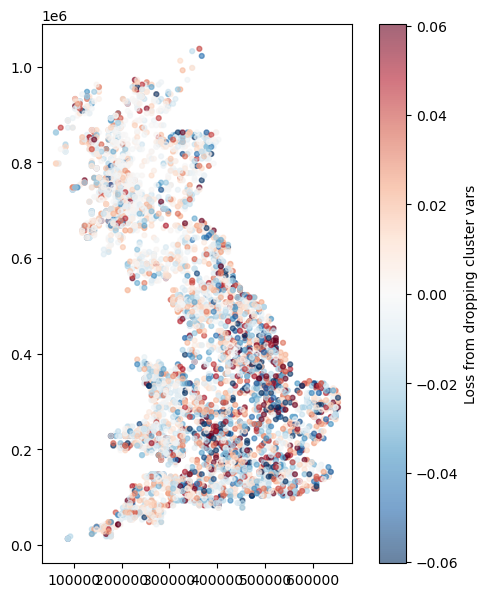

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(results['x_coord'], results['y_coord'], c=results['loss_from_dropping'],
                 cmap='RdBu_r', vmin=-results['loss_from_dropping'].abs().quantile(0.95),
                 vmax=results['loss_from_dropping'].abs().quantile(0.95), s=12, alpha=0.6)
plt.colorbar(sc, label='Loss from dropping cluster vars')
ax.set_aspect('equal')
plt.show()

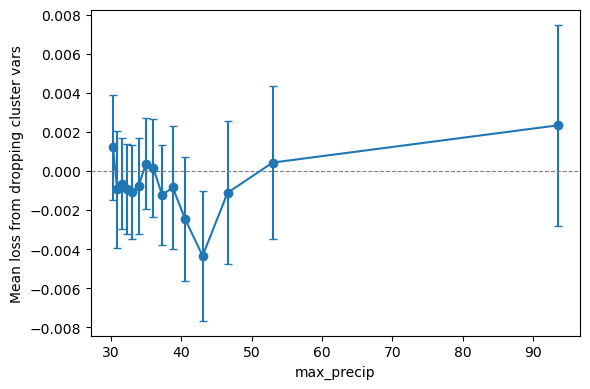

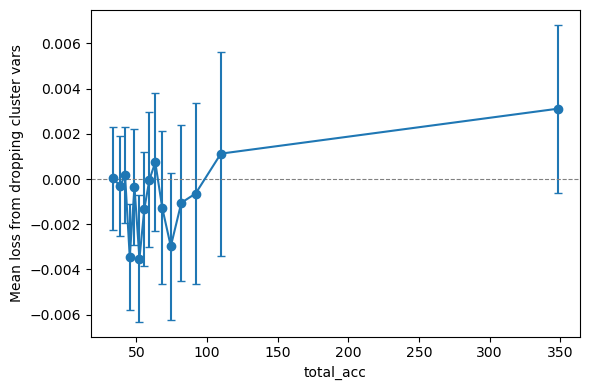

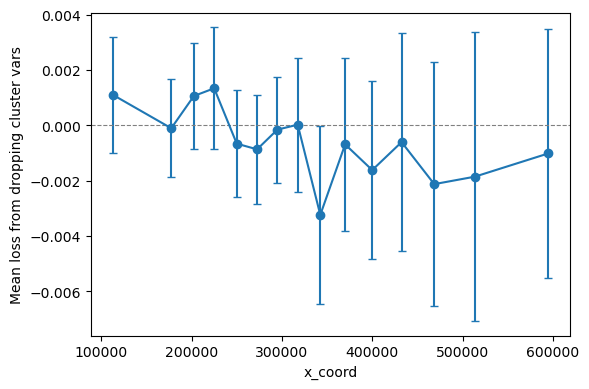

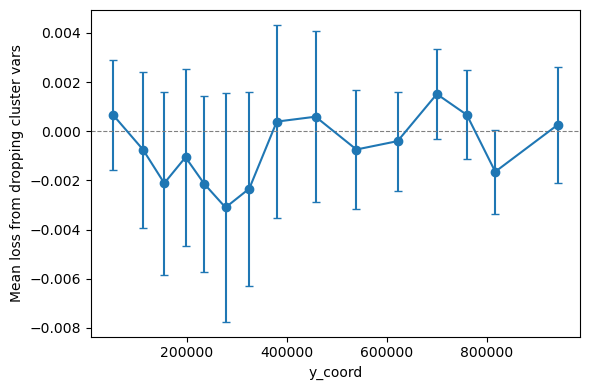

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def binned_effect_plot(var, results, n_bins=15, ax=None):
    bins = np.quantile(results[var].dropna(), np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)
    results['_bin'] = pd.cut(results[var], bins=bins, include_lowest=True)
    
    grouped = results.groupby('_bin', observed=True)['loss_from_dropping'].agg(['mean', 'sem', 'count'])
    bin_centers = [interval.mid for interval in grouped.index]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(bin_centers, grouped['mean'], yerr=1.96*grouped['sem'], marker='o', capsize=3)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel(var)
    ax.set_ylabel('Mean loss from dropping cluster vars')
    return ax

# check against candidate physical drivers - slope, TWI, or whatever you have
for var in ['max_precip', 'total_acc', 'x_coord', 'y_coord']:  # adjust to your actual columns
    if var in results.columns:
        fig, ax = plt.subplots(figsize=(6,4))
        binned_effect_plot(var, results, ax=ax)
        plt.tight_layout()
        plt.show()